In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas
import seaborn
import numpy
from scipy.interpolate import interp1d

%matplotlib inline
plt.rcParams['savefig.format'] = 'png'
plt.rcParams["font.family"] = 'serif'
plt.rcParams["font.size"] = 8
DATASETS = ["Erdös-Rényi","AQSOL", "PCQM4Mv2", "OGBN-Arxiv", "CoraFull"]

def table(BASE_DATASET):
    dataset_name = None
    if BASE_DATASET == "Erdös-Rényi":
        dataset_name = "er"
    elif BASE_DATASET == "AQSOL":
        dataset_name = "aqsol"
    elif BASE_DATASET == "PCQM4Mv2":
        dataset_name = "pcqm4mv2"
    elif BASE_DATASET == "OGBN-Arxiv":
        dataset_name = "ogbn-arxiv"
    elif BASE_DATASET == "CoraFull":
        dataset_name = "corafull"

    df = pandas.concat([pandas.read_csv(f"../results/run-{i}/{dataset_name}.csv").sort_values("Name").fillna("Laplacian") for i in range(8)])
    def path_to_noise(path: str) -> float:
        if "0.04" in path:
            return 0.04
        elif "0.06" in path:
            return 0.06
        elif "0.08" in path:
            return 0.08
        elif "0.12" in path:
            return 0.12
        elif "0.15" in path:
            return 0.15
        elif "0.18" in path:
            return 0.18
        elif "0.24" in path:
            return 0.24
        elif "0.3" in path:
            return 0.30
        
    median = df.groupby(["model","dataset"])["lap/val"].median()
    q_up = df.groupby(["model","dataset"])["lap/val"].quantile(0.95)
    q_down = df.groupby(["model","dataset"])["lap/val"].quantile(0.05)
    result_df = pandas.DataFrame(index=["GCN", "GIN", "GatedGCN", "GAT", "GATv2"], columns=[0.04, 0.06, 0.08, 0.12, 0.15, 0.18, 0.24, 0.30])
    uppererror_df = pandas.DataFrame(index=["GCN", "GIN", "GatedGCN", "GAT", "GATv2"], columns=[0.04, 0.06, 0.08, 0.12, 0.15, 0.18, 0.24, 0.30])
    lowererror_df = pandas.DataFrame(index=["GCN", "GIN", "GatedGCN", "GAT", "GATv2"], columns=[0.04, 0.06, 0.08, 0.12, 0.15, 0.18, 0.24, 0.30])
    

    for key in median.keys():
        if key[0] != "Laplacian":
            result_df.loc[key[0], path_to_noise(key[1])] = round(median[key]*100,1)
            uppererror_df.loc[key[0], path_to_noise(key[1])] = round(q_up[key]*100,1)
            lowererror_df.loc[key[0], path_to_noise(key[1])] = round(q_down[key]*100,1)

    if dataset_name == "corafull":
        result_df.loc["GIN", [0.04, 0.06, 0.08]] = [79.4, 74.3, 68.4]
        uppererror_df.loc["GIN", [0.04, 0.06, 0.08]] = [79.9, 74.9, 67.5]
        lowererror_df.loc["GIN", [0.04, 0.06, 0.08]] = [79.05, 73.1, 66.8]

    

    return result_df, uppererror_df, lowererror_df


In [42]:
DATASET = DATASETS[1]
df, uppererrors_df, lowererrors_df = table(DATASET)
models = ["GCN", "GIN", "GatedGCN", "GAT", "GATv2"]
noises = [0.04, 0.06, 0.08, 0.12, 0.15, 0.18, 0.24, 0.30]
lines = []
uppererrors = []
lowererrors = []
minvals = numpy.min(df.to_numpy(), axis=0)
for model in models:
    lines.append(df.loc[model,:].to_numpy().flatten() - minvals.flatten())
    uppererrors.append(uppererrors_df.loc[model,:].to_numpy().flatten()-df.loc[model,:].to_numpy().flatten())
    lowererrors.append(df.loc[model,:].to_numpy().flatten() - lowererrors_df.loc[model,:].to_numpy().flatten())

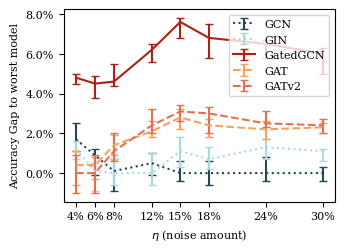

In [43]:
COLORS = ["#264653", "#a8dadc", "#ae2012", "#f4a261", "#e76f51"]
LINESTYLE = [":", ":", "-", "--", "--"]
fig, ax = plt.subplots(figsize=(3.5,2.5))
for line, uppererror, lowererror, c, ls, model in zip(lines, uppererrors, lowererrors, COLORS, LINESTYLE, models):
    # plt.plot(noises, line, color=c, ls=ls)
    ax.errorbar(noises, line/100, yerr=[numpy.clip(lowererror/100, 0,0.01), numpy.clip(uppererror/100, 0,0.01)], color=c, capsize=3, fmt=ls, ecolor=c, label=model)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xticks(noises)
ax.set_xticklabels(["4%","6%","8%","12%","15%","18%", "24%", "30%"])
ax.set_xlabel(r"$\eta$ (noise amount)")
ax.set_ylabel("Accuracy Gap to worst model")
plt.legend()
plt.savefig(f"../ranking-figs/ranking-{DATASET}.pdf", bbox_inches='tight', pad_inches=0.15)